<a href="https://colab.research.google.com/github/iking919/Detecting_Financial_Fraud_via_GNNs/blob/overhaul/07_Results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Detecting Financial Fraud via Graph Neural Networks: A Multi-Dataset, Graph-Based Learning Approach
##Haoyuan Chen, Izaak King, Bryan Gelnett

# Result Comparison

First loading in saved model results

### 1. Consolidated Results Table
This section loads the comprehensive results for all models (Baseline, GCN, and GraphSAGE) from Google Drive. We calculate key metrics including **AUC-PR**, **AUC-ROC**, **F1**, **Precision**, and **Recall**. The table is consolidated and sorted by Dataset and Model category to provide a high-level performance overview.

In [12]:
import os
import pickle
import pandas as pd
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

base_path = "/content/drive/MyDrive/GNN_fraud_Project/saved_models_and_results"

# Added GAT to the files to load
files_to_load = [
    ("baseline", "baseline/baseline_comprehensive_results.pkl"),
    ("GCN", "GCN/GCN_comprehensive_results.pkl"),
    ("GAT", "GAT/GAT_comprehensive_results.pkl"),
    ("graphSAGE", "graphSAGE/graphSAGE_comprehensive_results.pkl"),
]

all_loaded_results = {}
summary_data = []

for source_tag, rel_path in files_to_load:
    file_path = os.path.join(base_path, rel_path)
    if os.path.exists(file_path):
        with open(file_path, "rb") as f:
            data = pickle.load(f)
            for dataset_raw, models in data.items():
                clean_dataset = dataset_raw.replace(" Full-batch", "").replace(
                    " Mini-batch", ""
                )

                if clean_dataset not in all_loaded_results:
                    all_loaded_results[clean_dataset] = {}

                if isinstance(models, dict) and "y_true" in models:
                    model_items = {dataset_raw: models}.items()
                else:
                    model_items = models.items()

                for model_name, metrics in model_items:
                    if not isinstance(metrics, dict) or "y_true" not in metrics:
                        continue

                    display_model_name = f"{model_name} ({source_tag})"
                    all_loaded_results[clean_dataset][display_model_name] = metrics

                    # Sort order: baseline=0, GCN=1, GAT=2, graphSAGE=3
                    sort_map = {"baseline": 0, "GCN": 1, "GAT": 2, "graphSAGE": 3}
                    sort_rank = sort_map.get(source_tag, 99)

                    y_true = metrics["y_true"]
                    y_prob = metrics["probs"]
                    y_pred = metrics["preds"]

                    summary_data.append({
                        "Dataset": clean_dataset,
                        "Model": display_model_name,
                        "AUC-PR": average_precision_score(y_true, y_prob),
                        "AUC-ROC": roc_auc_score(y_true, y_prob),
                        "F1 (Fraud)": f1_score(y_true, y_pred, zero_division=0),
                        "Precision (Fraud)": precision_score(y_true, y_pred, zero_division=0),
                        "Recall (Fraud)": recall_score(y_true, y_pred, zero_division=0),
                        "_sort_rank": sort_rank,
                    })

if summary_data:
    summary_df = pd.DataFrame(summary_data).sort_values(
        ["Dataset", "_sort_rank", "AUC-ROC"], ascending=[True, True, False]
    )
    display(
        summary_df.drop(columns=["_sort_rank"])
        .style.hide(axis="index")
        .format(precision=4)
    )
else:
    print("No results loaded. Please check if GAT directory and .pkl file exist in Drive.")

Dataset,Model,AUC-PR,AUC-ROC,F1 (Fraud),Precision (Fraud),Recall (Fraud)
Elliptic,Logistic Regression (baseline),0.2138,0.8409,0.2992,0.2047,0.5560
Elliptic,MLP (baseline),0.3532,0.8381,0.4316,0.5897,0.3404
Elliptic,Random Forest (baseline),0.5860,0.8233,0.4936,0.4630,0.5285
Elliptic,Elliptic Full-batch (GCN),0.8624,0.9712,0.8383,0.8653,0.8130
Elliptic,Elliptic Mini-batch (GCN),0.8228,0.9697,0.6247,0.4707,0.9285
Elliptic,Elliptic Full-batch (GAT),0.8589,0.9726,0.8083,0.8216,0.7954
Elliptic,Elliptic Mini-batch (GAT),0.7623,0.9552,0.4228,0.2696,0.9791
Elliptic,Elliptic Mini-batch (graphSAGE),0.9172,0.9812,0.6322,0.4741,0.9483
Elliptic,Elliptic Full-batch (graphSAGE),0.9251,0.9797,0.8743,0.9188,0.8339
IEEE-CIS,MLP (baseline),0.3559,0.8434,0.3951,0.4142,0.3777


### 2. Identifying Best Performing Models by Metric
In this step, we derive specialized tables to highlight which model achieved the highest score for each specific metric (e.g., the model with the highest Recall for each dataset). This allows for a quick comparison of model strengths, such as identifying which architecture is most effective at minimizing false negatives (Recall) versus maximizing overall classification quality (AUC-ROC).

In [13]:
from sklearn.metrics import average_precision_score
import pandas as pd

# Prepare expanded summary data including AUC-PR
expanded_summary = []
for dataset, models in all_loaded_results.items():
    for model_name, metrics in models.items():
        y_true = metrics['y_true']
        y_prob = metrics['probs']
        y_pred = metrics['preds']

        expanded_summary.append({
            'Dataset': dataset,
            'Model': model_name,
            'AUC-PR': average_precision_score(y_true, y_prob),
            'AUC-ROC': roc_auc_score(y_true, y_prob),
            'F1 (Fraud)': f1_score(y_true, y_pred, zero_division=0),
            'Recall (Fraud)': recall_score(y_true, y_pred, zero_division=0),
            'Precision (Fraud)': precision_score(y_true, y_pred, zero_division=0)
        })

df_expanded = pd.DataFrame(expanded_summary)
metrics_to_show = ['AUC-ROC', 'Recall (Fraud)', 'F1 (Fraud)', 'Precision (Fraud)', 'AUC-PR']

for metric in metrics_to_show:
    print(f"\n--- Best Models by {metric} ---")
    # Get index of max value for the metric per dataset
    idx = df_expanded.groupby('Dataset')[metric].idxmax()
    best_df = df_expanded.loc[idx].sort_values(metric, ascending=False)
    display(best_df.style.hide(axis='index').format(precision=4))


--- Best Models by AUC-ROC ---


Dataset,Model,AUC-PR,AUC-ROC,F1 (Fraud),Recall (Fraud),Precision (Fraud)
PaySim,Random Forest (baseline),0.4355,0.9943,0.3927,0.8811,0.2526
Elliptic,Elliptic Mini-batch (graphSAGE),0.9172,0.9812,0.6322,0.9483,0.4741
IEEE-CIS,IEEE-CIS Full-batch (graphSAGE),0.5603,0.9146,0.5571,0.4583,0.7104



--- Best Models by Recall (Fraud) ---


Dataset,Model,AUC-PR,AUC-ROC,F1 (Fraud),Recall (Fraud),Precision (Fraud)
IEEE-CIS,IEEE-CIS Mini-batch (GCN),0.1518,0.7653,0.0677,0.9998,0.0350
Elliptic,Elliptic Mini-batch (GAT),0.7623,0.9552,0.4228,0.9791,0.2696
PaySim,Random Forest (baseline),0.4355,0.9943,0.3927,0.8811,0.2526



--- Best Models by F1 (Fraud) ---


Dataset,Model,AUC-PR,AUC-ROC,F1 (Fraud),Recall (Fraud),Precision (Fraud)
Elliptic,Elliptic Full-batch (graphSAGE),0.9251,0.9797,0.8743,0.8339,0.9188
PaySim,MLP (baseline),0.5906,0.8729,0.6098,0.4394,0.9963
IEEE-CIS,IEEE-CIS Full-batch (graphSAGE),0.5603,0.9146,0.5571,0.4583,0.7104



--- Best Models by Precision (Fraud) ---


Dataset,Model,AUC-PR,AUC-ROC,F1 (Fraud),Recall (Fraud),Precision (Fraud)
PaySim,MLP (baseline),0.5906,0.8729,0.6098,0.4394,0.9963
Elliptic,Elliptic Full-batch (graphSAGE),0.9251,0.9797,0.8743,0.8339,0.9188
IEEE-CIS,IEEE-CIS Full-batch (graphSAGE),0.5603,0.9146,0.5571,0.4583,0.7104



--- Best Models by AUC-PR ---


Dataset,Model,AUC-PR,AUC-ROC,F1 (Fraud),Recall (Fraud),Precision (Fraud)
Elliptic,Elliptic Full-batch (graphSAGE),0.9251,0.9797,0.8743,0.8339,0.9188
PaySim,MLP (baseline),0.5906,0.8729,0.6098,0.4394,0.9963
IEEE-CIS,IEEE-CIS Full-batch (graphSAGE),0.5603,0.9146,0.5571,0.4583,0.7104


### 3. Visual Comparison: Overlaid ROC Curves
To visualize the trade-off between the True Positive Rate and False Positive Rate, we generate overlaid ROC curves for each dataset. This graphical representation allows us to see the performance of all models simultaneously, where a larger Area Under the Curve (AUC) indicates superior discriminative ability.

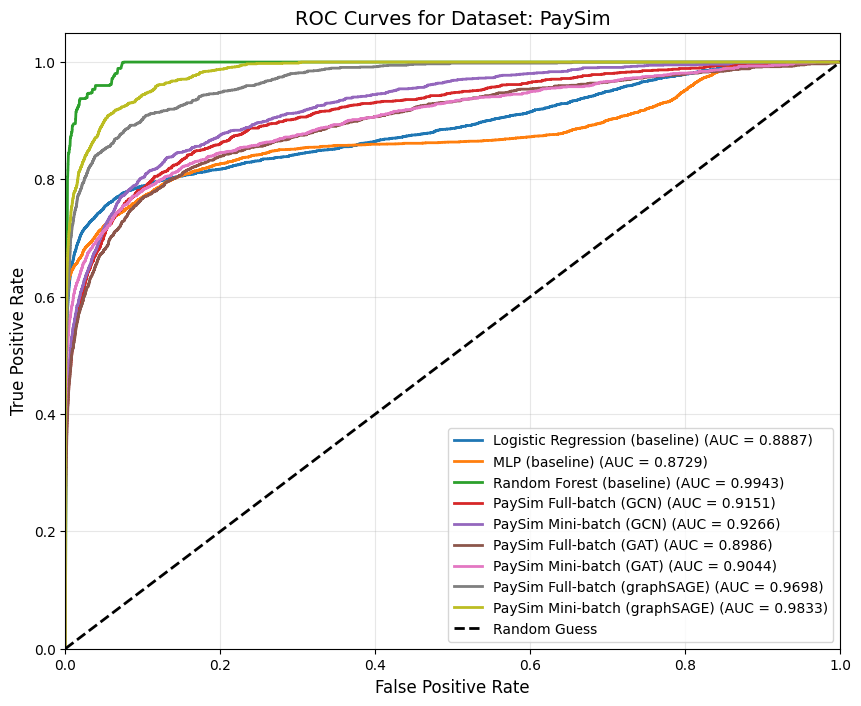

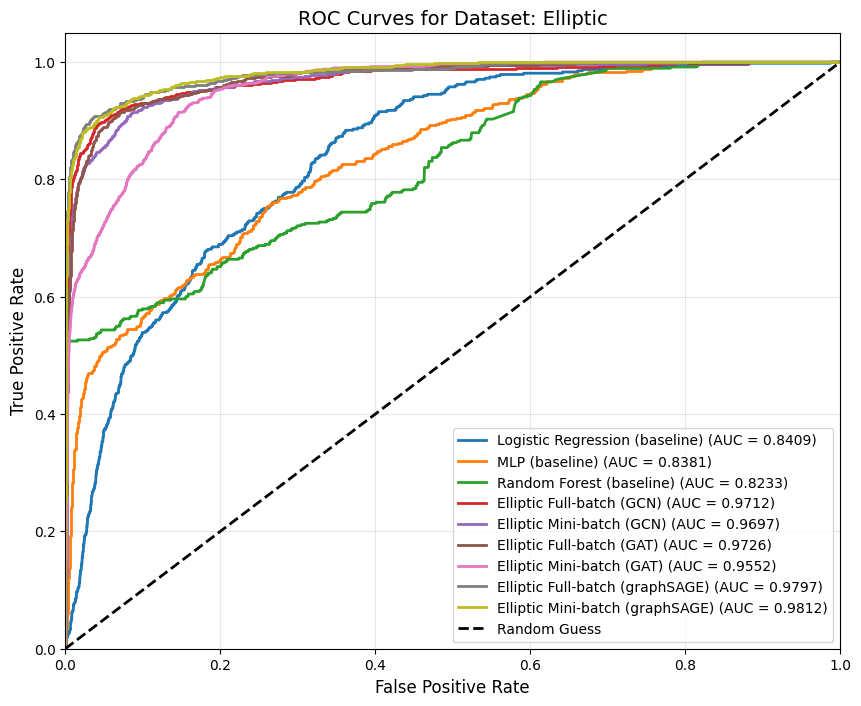

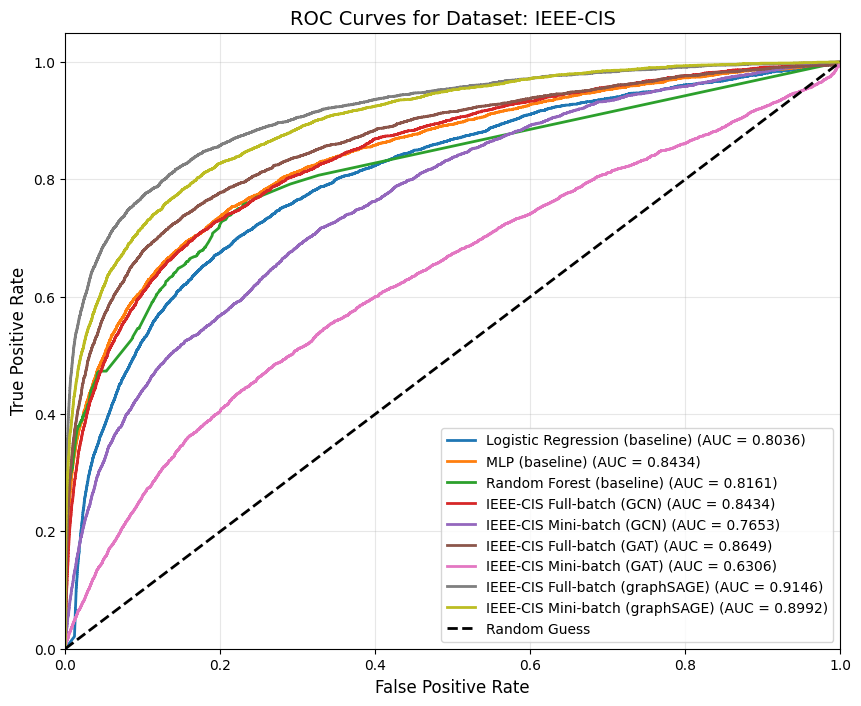

In [14]:
import matplotlib.pyplot as plt

# Plot overlaid ROC curves for each dataset
if all_loaded_results:
    for dataset, models in all_loaded_results.items():
        plt.figure(figsize=(10, 8))

        for model_name, metrics in models.items():
            y_true = metrics['y_true']
            y_prob = metrics['probs']

            # Calculate False Positive Rate and True Positive Rate
            fpr, tpr, _ = roc_curve(y_true, y_prob)
            auc = roc_auc_score(y_true, y_prob)

            # Plot the curve for this specific model
            plt.plot(fpr, tpr, lw=2, label=f"{model_name} (AUC = {auc:.4f})")

        # Plot random guessing baseline
        plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label='Random Guess')

        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate', fontsize=12)
        plt.ylabel('True Positive Rate', fontsize=12)
        plt.title(f'ROC Curves for Dataset: {dataset}', fontsize=14)
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
        plt.show()